### Retrain base Agents


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

from stable_baselines3 import PPO, SAC, A2C
from stable_baselines3.common.vec_env import DummyVecEnv
import torch as th

from environments_part1 import TechnicalAgentEnv, SentimentAgentEnv, ValidationCallback

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

DATA_DIR = '../data_hierarchical'
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)
th.manual_seed(SEED)

print("Imports complete\n")

# Load metadata
print("="*70)
print("DATA VERIFICATION")
print("="*70)

with open(Path(DATA_DIR) / 'metadata.json', 'r') as f:
    metadata = json.load(f)

print("\nPortfolio Tickers:", metadata['tickers'])
print(f"Date Range: {metadata['date_range']['start']} to {metadata['date_range']['end']}")
print(f"Splits: Train={metadata['splits']['train']:.0%}, Val={metadata['splits']['val']:.0%}, Test={metadata['splits']['test']:.0%}")
print(f"\nTechnical Features ({len(metadata['technical_features'])}):", metadata['technical_features'])
print(f"\nSentiment Features ({len(metadata['sentiment_features'])}):", metadata['sentiment_features'])

tech_train = pd.read_csv(Path(DATA_DIR) / 'technical' / 'train.csv', index_col=0, parse_dates=True)
sent_train = pd.read_csv(Path(DATA_DIR) / 'sentiment' / 'train.csv', index_col=0, parse_dates=True)
returns_train = pd.read_csv(Path(DATA_DIR) / 'returns_train.csv', index_col=0, parse_dates=True)

print(f"\nTechnical data: {tech_train.shape}")
print(f"Sentiment data: {sent_train.shape}")
print(f"Returns data: {returns_train.shape}")
print(f"Date range: {tech_train.index.min()} to {tech_train.index.max()}")

# Training configuration
print("\n" + "="*70)
print("TRAINING CONFIGURATION")
print("="*70)

TRAIN_CONFIG = {
    'total_steps': 300_000,
    'eval_freq': 5_000,
    'patience': 5,
    'learning_rate': 3e-4,
    'gamma': 0.99,
    'rolling_vol_window': 12,
    'softmax_temperature': 3.0,
}

ALGORITHMS = ['PPO', 'SAC', 'A2C']

print("\nTraining Configuration:")
for k, v in TRAIN_CONFIG.items():
    print(f"  {k}: {v}")
print(f"\nAlgorithms to test: {ALGORITHMS}\n")


def train_agent(agent_type, algorithm, config, verbose=True):
    """Train a single agent with given algorithm."""
    if verbose:
        print(f"\n{'='*70}")
        print(f"Training {agent_type.upper()} Agent with {algorithm}")
        print(f"{'='*70}")
    
    if agent_type == 'technical':
        train_env = TechnicalAgentEnv(
            DATA_DIR, 'train',
            rolling_vol_window=config['rolling_vol_window'],
            softmax_temperature=config['softmax_temperature'],
            random_start=True
        )
        val_env = TechnicalAgentEnv(
            DATA_DIR, 'val',
            rolling_vol_window=config['rolling_vol_window'],
            softmax_temperature=config['softmax_temperature']
        )
        test_env = TechnicalAgentEnv(
            DATA_DIR, 'test',
            rolling_vol_window=config['rolling_vol_window'],
            softmax_temperature=config['softmax_temperature']
        )
    else:
        train_env = SentimentAgentEnv(
            DATA_DIR, 'train',
            rolling_vol_window=config['rolling_vol_window'],
            softmax_temperature=config['softmax_temperature'],
            random_start=True
        )
        val_env = SentimentAgentEnv(
            DATA_DIR, 'val',
            rolling_vol_window=config['rolling_vol_window'],
            softmax_temperature=config['softmax_temperature']
        )
        test_env = SentimentAgentEnv(
            DATA_DIR, 'test',
            rolling_vol_window=config['rolling_vol_window'],
            softmax_temperature=config['softmax_temperature']
        )
    
    vec_env = DummyVecEnv([lambda: train_env])
    
    model_kwargs = {
        'policy': 'MlpPolicy',
        'env': vec_env,
        'learning_rate': config['learning_rate'],
        'gamma': config['gamma'],
        'seed': SEED,
        'verbose': 0 if not verbose else 1,
    }
    
    if algorithm == 'PPO':
        model = PPO(
            **model_kwargs,
            n_steps=2048,
            batch_size=512,
            policy_kwargs=dict(
                activation_fn=th.nn.ReLU,
                net_arch=[256, 256]
            ),
        )
    elif algorithm == 'SAC':
        model = SAC(
            **model_kwargs,
            buffer_size=200_000,
            batch_size=1024,
            policy_kwargs=dict(
                activation_fn=th.nn.ReLU,
                net_arch=dict(pi=[256, 256], qf=[256, 256])
            )
        )
    elif algorithm == 'A2C':
        model = A2C(
            **model_kwargs,
            n_steps=5,
            policy_kwargs=dict(
                activation_fn=th.nn.ReLU,
                net_arch=[256, 256]
            )
        )
    else:
        raise ValueError(f"Unknown algorithm: {algorithm}")
    
    save_path = MODELS_DIR / agent_type / 'ema_sharpe' / f"best_{agent_type}_{algorithm.lower()}.zip"
    save_path.parent.mkdir(parents=True, exist_ok=True)
    callback = ValidationCallback(
        val_env=val_env,
        eval_freq=config['eval_freq'],
        patience=config['patience'],
        save_path=str(save_path),
        verbose=1 if verbose else 0
    )
    
    model.learn(
        total_timesteps=config['total_steps'],
        callback=callback
    )
    
    if save_path.exists():
        if algorithm == 'PPO':
            model = PPO.load(str(save_path), env=vec_env)
        elif algorithm == 'SAC':
            model = SAC.load(str(save_path), env=vec_env)
        elif algorithm == 'A2C':
            model = A2C.load(str(save_path), env=vec_env)
    
    train_sharpe = train_env.run_full_pass(model)
    val_sharpe = val_env.run_full_pass(model)
    test_sharpe = test_env.run_full_pass(model)
    
    if verbose:
        print(f"\nResults:")
        print(f"  Train Sharpe: {train_sharpe:.3f}")
        print(f"  Val Sharpe:   {val_sharpe:.3f}")
        print(f"  Test Sharpe:  {test_sharpe:.3f}")
        print(f"  Model saved:  {save_path}")
    
    return {
        'agent_type': agent_type,
        'algorithm': algorithm,
        'train_sharpe': train_sharpe,
        'val_sharpe': val_sharpe,
        'test_sharpe': test_sharpe,
        'model_path': str(save_path)
    }

Imports complete

DATA VERIFICATION

Portfolio Tickers: ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
Date Range: 2020-01-01 to 2025-10-23
Splits: Train=60%, Val=20%, Test=20%

Technical Features (26): ['open', 'high', 'low', 'close', 'volume', 'return', 'price_to_sma_4w', 'price_to_sma_8w', 'price_to_sma_12w', 'price_to_ema_8w', 'price_to_ema_12w', 'macd_histogram', 'return_lag_1w', 'return_lag_2w', 'return_lag_3w', 'rsi_14w', 'stochastic_14w', 'roc_4w', 'volatility_12w', 'atr_pct_14w', 'bb_position_20w', 'volume_ratio_20w', 'mfi_14w', 'obv_roc_4w', 'bench_corr_12w', 'bench_beta_12w']

Sentiment Features (18): ['open', 'high', 'low', 'close', 'volume', 'return', 'momentum_2w', 'momentum_4w', 'momentum_6w', 'positive_weeks_pct', 'price_dispersion', 'volume_sentiment', 'volume_surge', 'vol_regime', 'drawdown', 'market_fear', 'credit_sentiment', 'news_sentiment']

Technical data: (1407, 27)
Sentiment data: (1372, 19)
Returns data: (201, 7)
Date range: 2019-05-24 00:00:00 to 2023-

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


### Main training loop."""

In [ ]:
# Train Technical Agent
print("\n" + "="*70)
print("TRAINING TECHNICAL AGENT")
print("="*70)

technical_results = []
for algo in ALGORITHMS:
    result = train_agent('technical', algo, TRAIN_CONFIG, verbose=True)
    technical_results.append(result)

tech_df = pd.DataFrame(technical_results)
tech_df = tech_df.sort_values('val_sharpe', ascending=False)

print("\n" + "="*70)
print("TECHNICAL AGENT RESULTS")
print("="*70)
print(tech_df.to_string(index=False))

best_tech = tech_df.iloc[0].to_dict()
print(f"\nBest Technical Agent: {best_tech['algorithm']} (Val Sharpe: {best_tech['val_sharpe']:.3f})")

# Train Sentiment Agent
print("\n" + "="*70)
print("TRAINING SENTIMENT AGENT")
print("="*70)

sentiment_results = []
for algo in ALGORITHMS:
    result = train_agent('sentiment', algo, TRAIN_CONFIG, verbose=True)
    sentiment_results.append(result)

sent_df = pd.DataFrame(sentiment_results)
sent_df = sent_df.sort_values('val_sharpe', ascending=False)

print("\n" + "="*70)
print("SENTIMENT AGENT RESULTS")
print("="*70)
print(sent_df.to_string(index=False))

best_sent = sent_df.iloc[0].to_dict()
print(f"\nBest Sentiment Agent: {best_sent['algorithm']} (Val Sharpe: {best_sent['val_sharpe']:.3f})")

# Save best models configuration
best_models_config = {
    'technical': {
        'algorithm': best_tech['algorithm'],
        'model_path': best_tech['model_path'],
        'train_sharpe': float(best_tech['train_sharpe']),
        'val_sharpe': float(best_tech['val_sharpe']),
        'test_sharpe': float(best_tech['test_sharpe'])
    },
    'sentiment': {
        'algorithm': best_sent['algorithm'],
        'model_path': best_sent['model_path'],
        'train_sharpe': float(best_sent['train_sharpe']),
        'val_sharpe': float(best_sent['val_sharpe']),
        'test_sharpe': float(best_sent['test_sharpe'])
    },
    'training_config': TRAIN_CONFIG,
    'tickers': metadata['tickers'],
    'created_at': pd.Timestamp.now().isoformat()
}

config_path = MODELS_DIR / 'ema_sharpe_best_models.json'
with open(config_path, 'w') as f:
    json.dump(best_models_config, f, indent=2)

print(f"\nBest models configuration saved to {config_path}")

# Final summary
print("\n" + "="*70)
print("RETRAINING COMPLETE")
print("="*70)

print("\nTrained Agents:")
print(f"  1. Technical Agent: {best_tech['algorithm']} (Test Sharpe: {best_tech['test_sharpe']:.3f})")
print(f"  2. Sentiment Agent: {best_sent['algorithm']} (Test Sharpe: {best_sent['test_sharpe']:.3f})")

print("\nSaved Models:")
print(f"  Technical: {best_tech['model_path']}")
print(f"  Sentiment: {best_sent['model_path']}")
print(f"  Config: {config_path}")

print("\nKey Improvements:")
print("  - Complete technical indicator suite (20 features)")
print("  - Correct window sizes matching specification")
print("  - Added: EMA, MACD, Stochastic, Bollinger Bands, MFI, OBV")
print("  - Adjusted training parameters for better generalization")
print("  - Random start positions in training for better exploration")

print("\n" + "="*70)
print("Ready to proceed to Part 2 (Super Agent)!")
print("="*70)



TRAINING TECHNICAL AGENT

Training TECHNICAL Agent with PPO
TechnicalAgentEnv (train): 201 dates, 7 assets, 20 features
TechnicalAgentEnv (val): 66 dates, 7 assets, 20 features
TechnicalAgentEnv (test): 67 dates, 7 assets, 20 features
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1756 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1681        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009506485 |
|    clip_fraction        | 0.0946      |
|    clip_range           | 0.2         |
|    entropy_loss         | -9.94       |
|    explained_variance   | -0.013      |
|    learning_rate        | 0.000

## Visualization Functions

Define helper functions for creating comprehensive training visualizations.


In [ ]:
def plot_performance_comparison(results_df, title, save_path=None):
    """Create bar plot comparing train/val/test performance."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    x = np.arange(len(results_df))
    width = 0.25
    
    ax.bar(x - width, results_df['train_sharpe'], width, label='Train', alpha=0.8, color='#2ecc71')
    ax.bar(x, results_df['val_sharpe'], width, label='Val', alpha=0.8, color='#3498db')
    ax.bar(x + width, results_df['test_sharpe'], width, label='Test', alpha=0.8, color='#e74c3c')
    
    ax.set_ylabel('Sharpe Ratio', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['algorithm'])
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    for i, row in results_df.iterrows():
        ax.text(i, row['test_sharpe'] + 0.1, f"{row['test_sharpe']:.2f}", 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()


def plot_portfolio_allocations(model, env, metadata, title, save_path=None):
    """Plot portfolio weight allocations over time."""
    obs, _ = env.reset()
    weights_history = []
    returns_history = []
    dates = []
    done = False
    step = 0
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, info = env.step(action)
        if 'weights' in info:
            weights_history.append(info['weights'])
        if 'port_log_r' in info:
            returns_history.append(info['port_log_r'])
        step += 1
    
    weights_array = np.array(weights_history)
    weights_df = pd.DataFrame(weights_array, columns=metadata['tickers'])
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Stacked area plot
    weights_df.plot(kind='area', stacked=True, ax=ax1, alpha=0.7)
    ax1.set_title(f'{title} - Portfolio Allocations Over Time', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Weight', fontsize=12)
    ax1.set_xlabel('Week', fontsize=12)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax1.grid(alpha=0.3)
    ax1.set_ylim([0, 1])
    
    # Cumulative returns
    cumulative_returns = np.cumsum(returns_history)
    ax2.plot(cumulative_returns, linewidth=2, color='#2ecc71')
    ax2.fill_between(range(len(cumulative_returns)), 0, cumulative_returns, alpha=0.3, color='#2ecc71')
    ax2.set_title('Cumulative Returns', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Cumulative Log Return', fontsize=12)
    ax2.set_xlabel('Week', fontsize=12)
    ax2.grid(alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
    
    final_return = cumulative_returns[-1]
    ax2.text(len(cumulative_returns)*0.02, cumulative_returns[-1]*0.9, 
             f'Final Return: {final_return:.3f}', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()


def plot_risk_return_scatter(results_list, title, save_path=None):
    """Create risk-return scatter plot."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    for result in results_list:
        # Calculate return and volatility from Sharpe
        # Sharpe = Return / Vol, assume annualized
        test_sharpe = result['test_sharpe']
        algo = result['algorithm']
        
        ax.scatter(1, test_sharpe, s=200, alpha=0.7, label=algo)
        ax.annotate(f"{algo}\n({test_sharpe:.2f})", (1, test_sharpe), 
                   xytext=(10, 10), textcoords='offset points', fontsize=10,
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))
    
    ax.set_ylabel('Sharpe Ratio (Risk-Adjusted Return)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='Sharpe = 1.0')
    ax.legend(fontsize=10)
    ax.set_xlim([0.5, 1.5])
    ax.get_xaxis().set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()


def plot_generalization_gap(results_df, title, save_path=None):
    """Plot generalization gap (Val Sharpe - Test Sharpe)."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    results_df['gap'] = results_df['val_sharpe'] - results_df['test_sharpe']
    results_df['gap_pct'] = (results_df['gap'] / results_df['val_sharpe']) * 100
    
    colors = ['#e74c3c' if x > 0.5 else '#f39c12' if x > 0.2 else '#2ecc71' 
              for x in results_df['gap']]
    
    bars = ax.barh(results_df['algorithm'], results_df['gap'], color=colors, alpha=0.7)
    ax.set_xlabel('Val Sharpe - Test Sharpe', fontsize=12)
    ax.set_title(f'{title} - Generalization Gap (Lower is Better)', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.axvline(x=0.2, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Warning threshold')
    ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Overfitting threshold')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    
    for i, (gap, gap_pct) in enumerate(zip(results_df['gap'], results_df['gap_pct'])):
        ax.text(gap + 0.02, i, f'{gap:.2f} ({gap_pct:.1f}%)', 
                va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()


def create_summary_report(tech_results, sent_results, best_tech, best_sent):
    """Create comprehensive summary visualization."""
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # 1. Overall comparison
    ax1 = fig.add_subplot(gs[0, :])
    agents = ['Technical\n(Best)', 'Sentiment\n(Best)']
    train_scores = [best_tech['train_sharpe'], best_sent['train_sharpe']]
    val_scores = [best_tech['val_sharpe'], best_sent['val_sharpe']]
    test_scores = [best_tech['test_sharpe'], best_sent['test_sharpe']]
    
    x = np.arange(len(agents))
    width = 0.25
    
    ax1.bar(x - width, train_scores, width, label='Train', alpha=0.8, color='#2ecc71')
    ax1.bar(x, val_scores, width, label='Val', alpha=0.8, color='#3498db')
    ax1.bar(x + width, test_scores, width, label='Test', alpha=0.8, color='#e74c3c')
    
    ax1.set_ylabel('Sharpe Ratio', fontsize=12)
    ax1.set_title('Best Models Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{agents[0]}\n{best_tech['algorithm']}", 
                          f"{agents[1]}\n{best_sent['algorithm']}"])
    ax1.legend(fontsize=11)
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. Technical agent algorithms
    ax2 = fig.add_subplot(gs[1, 0])
    tech_df = pd.DataFrame(tech_results)
    ax2.bar(tech_df['algorithm'], tech_df['test_sharpe'], alpha=0.7, color='#3498db')
    ax2.set_ylabel('Test Sharpe', fontsize=11)
    ax2.set_title('Technical Agent - All Algorithms', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    for i, v in enumerate(tech_df['test_sharpe']):
        ax2.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
    
    # 3. Sentiment agent algorithms
    ax3 = fig.add_subplot(gs[1, 1])
    sent_df = pd.DataFrame(sent_results)
    ax3.bar(sent_df['algorithm'], sent_df['test_sharpe'], alpha=0.7, color='#e67e22')
    ax3.set_ylabel('Test Sharpe', fontsize=11)
    ax3.set_title('Sentiment Agent - All Algorithms', fontsize=12, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    for i, v in enumerate(sent_df['test_sharpe']):
        ax3.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
    
    # 4. Metrics table
    ax4 = fig.add_subplot(gs[2, :])
    ax4.axis('tight')
    ax4.axis('off')
    
    table_data = [
        ['Metric', 'Technical (PPO)', 'Sentiment (SAC)'],
        ['Algorithm', best_tech['algorithm'], best_sent['algorithm']],
        ['Train Sharpe', f"{best_tech['train_sharpe']:.3f}", f"{best_sent['train_sharpe']:.3f}"],
        ['Val Sharpe', f"{best_tech['val_sharpe']:.3f}", f"{best_sent['val_sharpe']:.3f}"],
        ['Test Sharpe', f"{best_tech['test_sharpe']:.3f}", f"{best_sent['test_sharpe']:.3f}"],
        ['Val-Test Gap', f"{best_tech['val_sharpe'] - best_tech['test_sharpe']:.3f}", 
         f"{best_sent['val_sharpe'] - best_sent['test_sharpe']:.3f}"],
        ['Generalization', 
         f"{((1 - (best_tech['val_sharpe'] - best_tech['test_sharpe']) / best_tech['val_sharpe']) * 100):.1f}%",
         f"{((1 - (best_sent['val_sharpe'] - best_sent['test_sharpe']) / best_sent['val_sharpe']) * 100):.1f}%"]
    ]
    
    table = ax4.table(cellText=table_data, cellLoc='center', loc='center',
                      colWidths=[0.3, 0.35, 0.35])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)
    
    for i in range(len(table_data[0])):
        table[(0, i)].set_facecolor('#34495e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    for i in range(1, len(table_data)):
        for j in range(len(table_data[0])):
            if j == 0:
                table[(i, j)].set_facecolor('#ecf0f1')
                table[(i, j)].set_text_props(weight='bold')
            else:
                table[(i, j)].set_facecolor('#ffffff')
    
    plt.suptitle('Training Summary Report', fontsize=16, fontweight='bold', y=0.98)
    
    #plt.savefig('training_summary_report.png', dpi=150, bbox_inches='tight')
    plt.show()


print("Visualization functions loaded")


In [6]:
# Load best technical model
if best_tech['algorithm'] == 'PPO':
    best_tech_model = PPO.load(best_tech['model_path'])
elif best_tech['algorithm'] == 'SAC':
    best_tech_model = SAC.load(best_tech['model_path'])
else:
    best_tech_model = A2C.load(best_tech['model_path'])

# Load best sentiment model
if best_sent['algorithm'] == 'PPO':
    best_sent_model = PPO.load(best_sent['model_path'])
elif best_sent['algorithm'] == 'SAC':
    best_sent_model = SAC.load(best_sent['model_path'])
else:
    best_sent_model = A2C.load(best_sent['model_path'])

print(f"Loaded best models: Technical ({best_tech['algorithm']}), Sentiment ({best_sent['algorithm']})")


Loaded best models: Technical (PPO), Sentiment (SAC)


In [7]:
# Create test environments
tech_test_env = TechnicalAgentEnv(DATA_DIR, 'test', 
                                   rolling_vol_window=TRAIN_CONFIG['rolling_vol_window'],
                                   softmax_temperature=TRAIN_CONFIG['softmax_temperature'])

sent_test_env = SentimentAgentEnv(DATA_DIR, 'test',
                                   rolling_vol_window=TRAIN_CONFIG['rolling_vol_window'],
                                   softmax_temperature=TRAIN_CONFIG['softmax_temperature'])

print("Test environments created")


TechnicalAgentEnv (test): 67 dates, 7 assets, 20 features
SentimentAgentEnv (test): 67 dates, 7 assets, 12 features
Test environments created


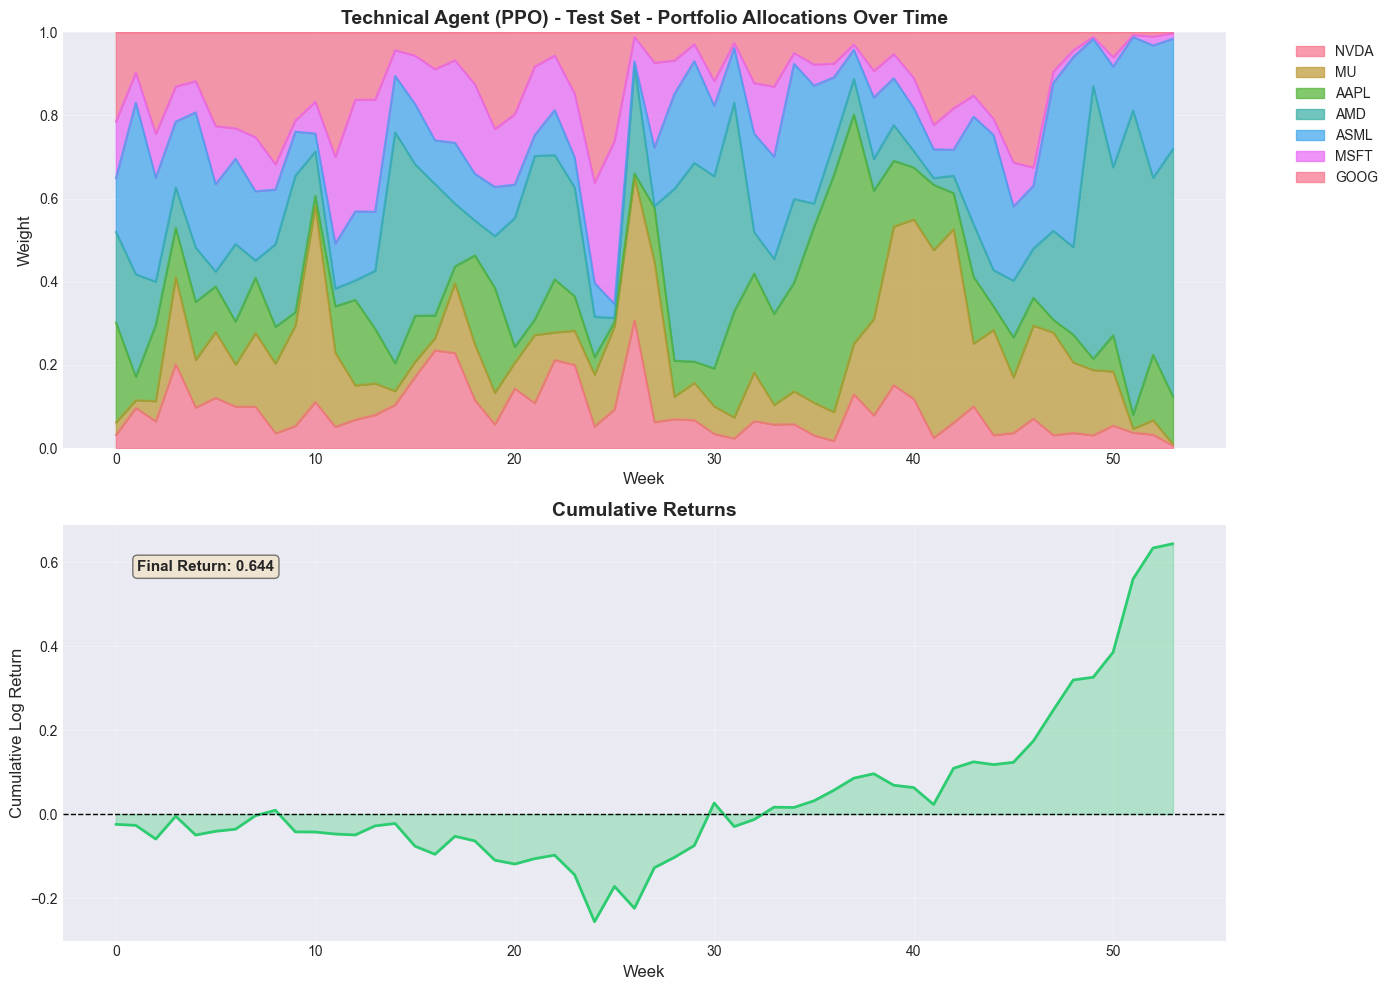

In [8]:
plot_portfolio_allocations(best_tech_model, tech_test_env, metadata, 
                           f"Technical Agent ({best_tech['algorithm']}) - Test Set",
                           save_path='tech_portfolio.png')


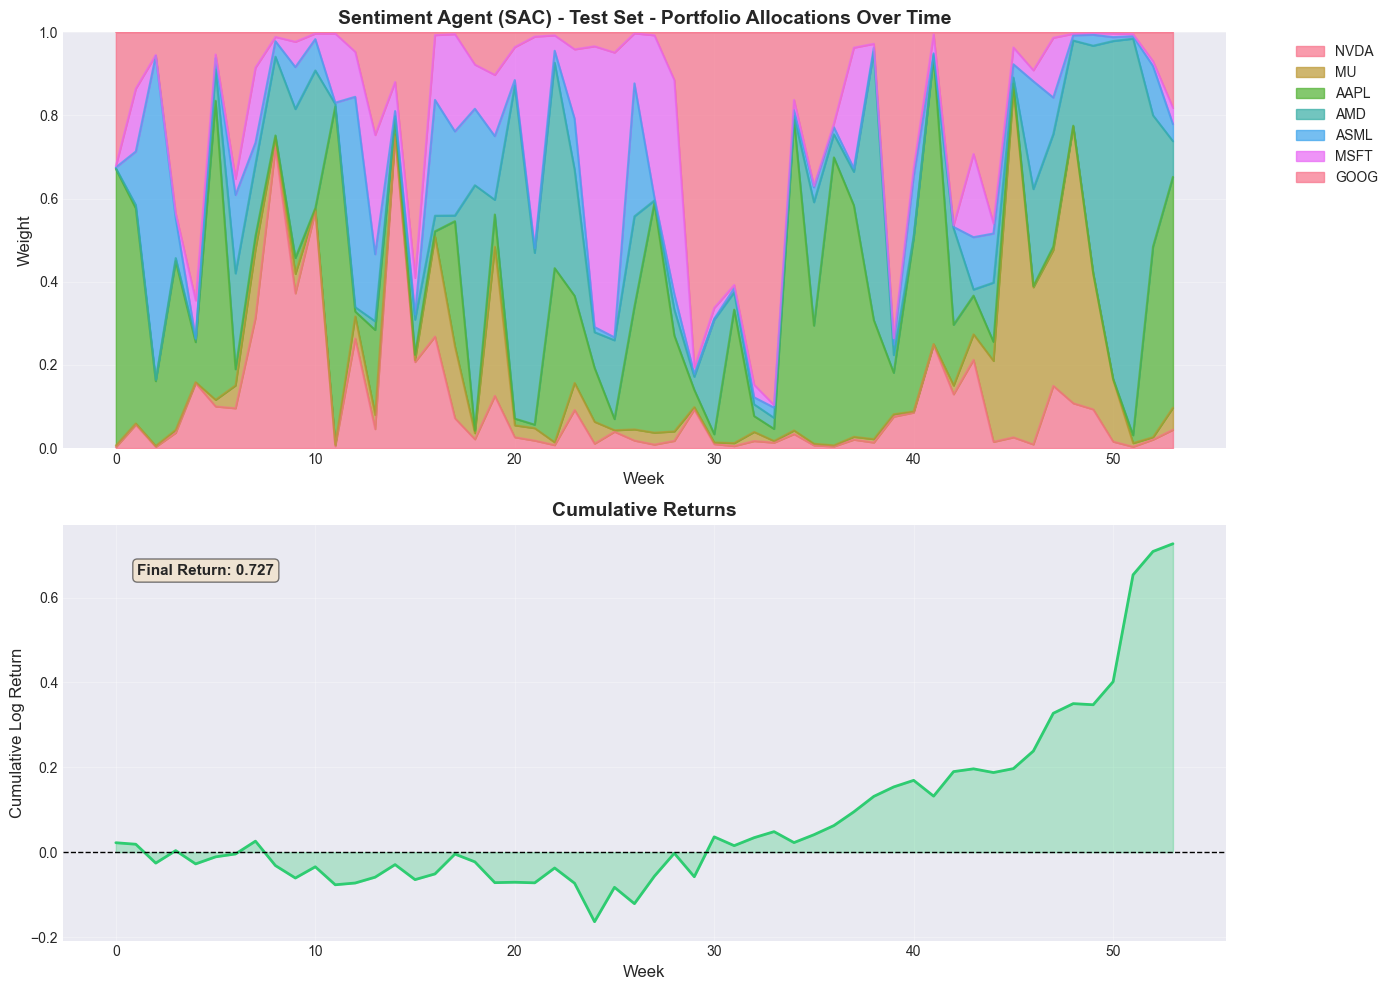

In [ ]:
plot_portfolio_allocations(best_sent_model, sent_test_env, metadata,
                           f"Sentiment Agent ({best_sent['algorithm']}) - Test Set",
                           save_path='sent_portfolio.png')


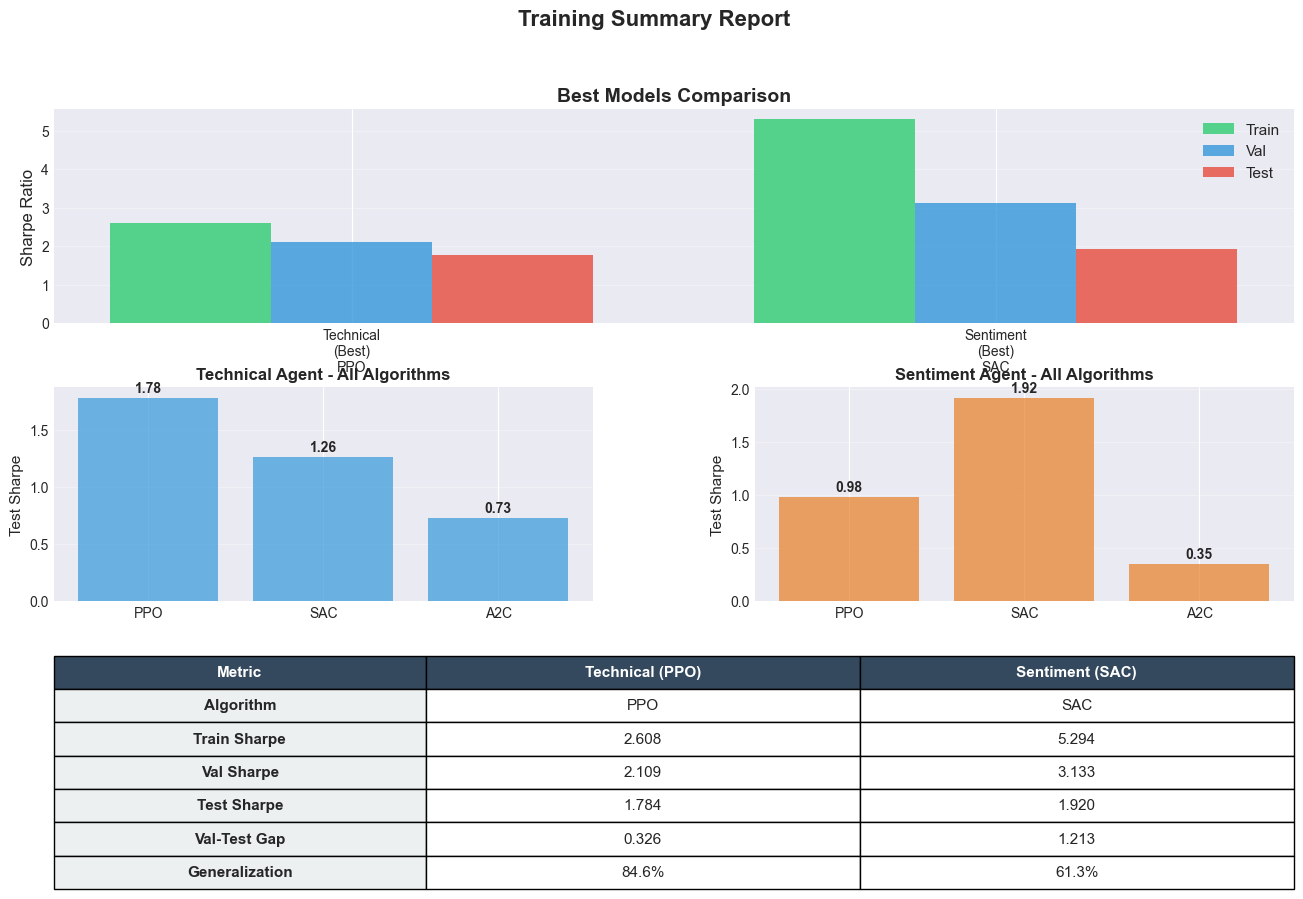

In [10]:
create_summary_report(technical_results, sentiment_results, best_tech, best_sent)


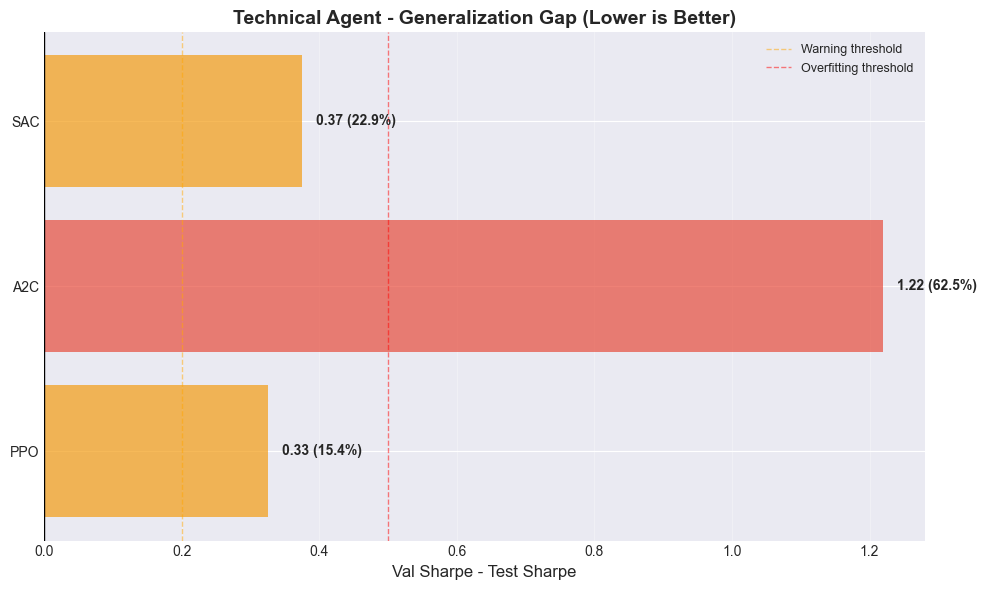

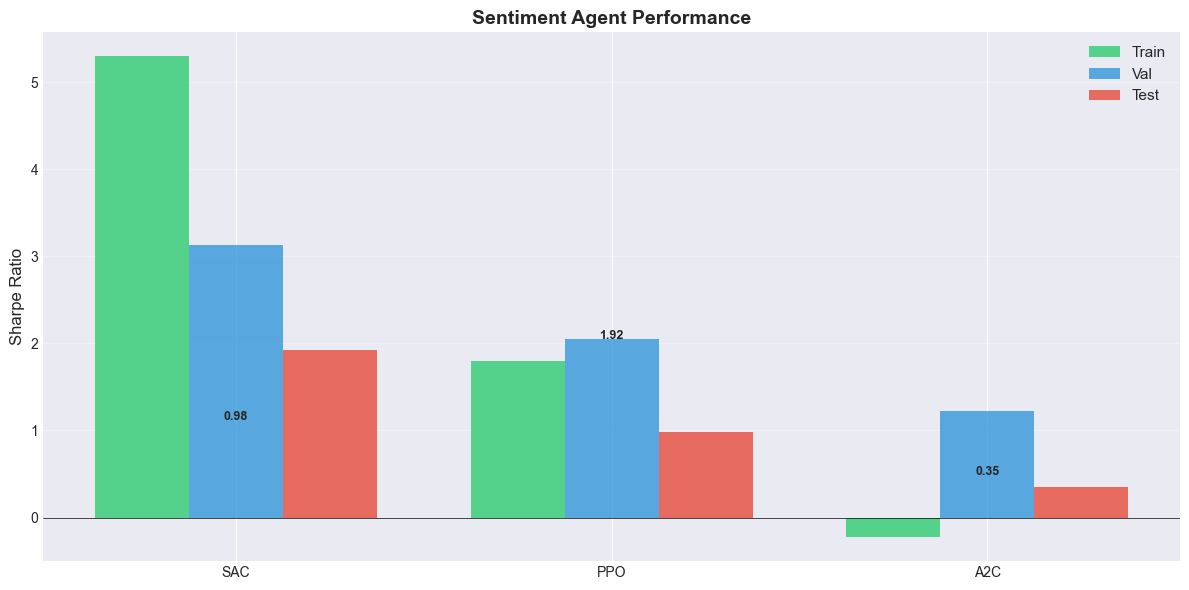

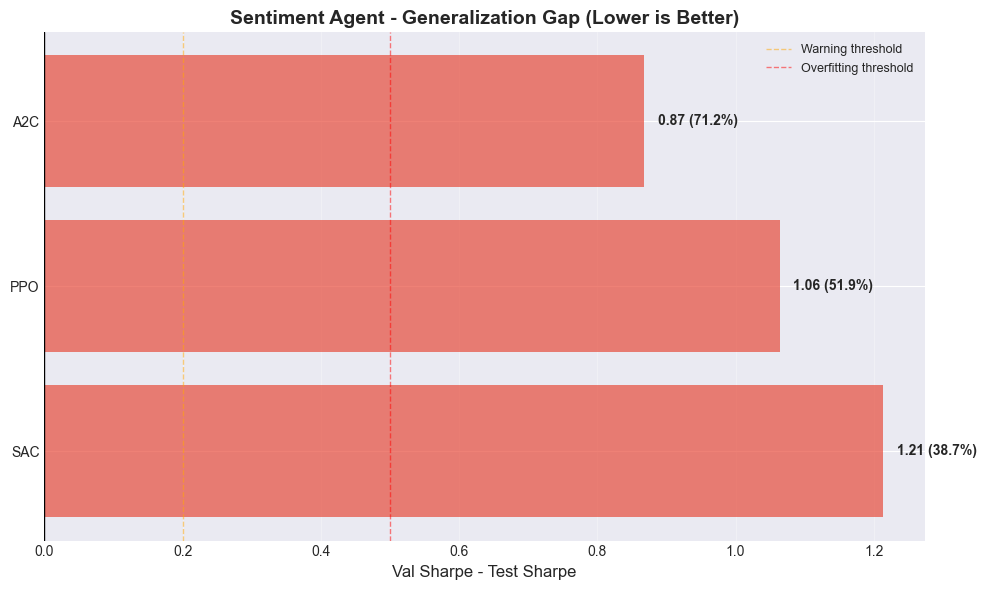

In [12]:
plot_generalization_gap(tech_df.copy(), 'Technical Agent', save_path='tech_generalization.png')
plot_performance_comparison(sent_df, 'Sentiment Agent Performance', save_path='sent_performance.png')
plot_generalization_gap(sent_df.copy(), 'Sentiment Agent', save_path='sent_generalization.png')
